Feed Forward Network con PyTorch

Axel Daniel Nuño | T035859

Aquí básicamente declaramos y dejamos todo listo para empezar a trabajar bien sin problemas con las librerias (es importante activar tu ambiente virtual y que este contenga las librerias). Estamos usando PyTorch para todo lo del modelo, torchvision para traer MNIST, matplotlib para visualizar y tqdm para ver el avance del entrenamiento

In [20]:
import copy
import math
import torch
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm.auto import tqdm

Aquí ya cargamos MNIST directamente como dataset de PyTorch y hacemos la separación correcta. De los 60,000 de entrenamiento, separamos 10,000 para validación y nos quedamos con 50,000 para train. También fijamos la semilla para que los resultados sean consistentes y no cambien cada vez que corremos todo.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

trainval_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    trainval_dataset,
    [50000, 10000],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))
print("Device:", device)

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.70MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 272kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.93MB/s]

Train: 50000
Val: 10000
Test: 10000
Device: cpu


Este paso es más para validar visualmente que todo esté bien cargado. Así lo dejamos porque así confirmamos que sí estamos trabajando con MNIST correctamente antes de entrenar cualquier cosa.

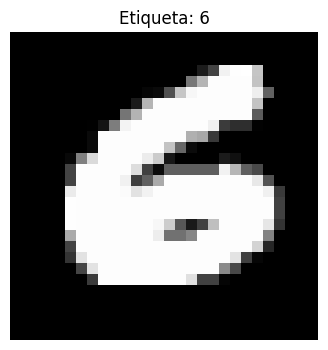

In [3]:
sample_image, sample_label = train_dataset[0]
plt.figure(figsize=(4, 4))
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(f"Etiqueta: {sample_label}")
plt.axis("off")
plt.show()

Aquí dejamos una función para generar los DataLoader dependiendo del batch size que se quieran usar. Esto  sirve mucho porque vamos a probar diferentes configuraciones, entonces así no repetimos código cada vez.

In [5]:
def build_dataloader(batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

Aquí definimos la red neuronal. Es una red fully connected usando solo nn.Linear y nn.ReLU. La hicimos flexible para poder cambiar fácilmente la arquitectura, por ejemplo el número de capas ocultas y neuronas por capa.

In [6]:
class MNISTMLP(nn.Module):
    def __init__(self, hidden_layers):
        super().__init__()
        layers = []
        input_dim = 28 * 28

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

Definimos la función de pérdida. Usamos cross entropy porque es un problema de clasificación multiclase con 10 clases. Esta función ya maneja todo internamente, así que no necesitamos aplicar softmax manualmente.

In [7]:
criterion = nn.CrossEntropyLoss()

Esta función la usamos para evaluar el modelo en validación o test. Nos regresa tanto la pérdida como el accuracy, y así podemos monitorear el desempeño al final de cada época.

In [8]:
def compute_loss_and_accuracy(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy

Aquí implementamos early stopping. La idea es que si la pérdida de validación deja de mejorar lo suficiente durante varias épocas, se detiene el entrenamiento para no seguir perdiendo tiempo y evitar sobreajuste.

In [9]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0.005):
        self.patience = patience
        self.delta = delta
        self.best_loss = math.inf
        self.counter = 0
        self.best_state = None
        self.stop = False

    def step(self, current_loss, model):
        if self.best_loss - current_loss > self.delta:
            self.best_loss = current_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

Aquí ya está todo el loop de entrenamiento completo. Cada época recorre todo el dataset de train, se entrena por mini batches y al final se evalúa en validación. También integro el early stopping para que se detenga automáticamente si ya no mejora.

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, patience=3, delta=0.005):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    early_stopping = EarlyStopping(patience=patience, delta=delta)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total_samples = 0

        progress_bar = tqdm(train_loader, desc=f"Época {epoch + 1}/{epochs}", leave=False)

        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * images.size(0)
            running_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            progress_bar.set_postfix(loss=loss.item())

        train_loss = running_loss / total_samples
        train_acc = running_correct / total_samples
        val_loss, val_acc = compute_loss_and_accuracy(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Época {epoch + 1}/{epochs} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

        early_stopping.step(val_loss, model)

        if early_stopping.stop:
            print("Entrenamiento detenido por early stopping")
            break

    if early_stopping.best_state is not None:
        model.load_state_dict(early_stopping.best_state)

    return history

Aquí definimos tres configuraciones diferentes para cumplir con la parte de experimentar. Cambiamos arquitectura, optimizador, batch size, learning rate y número de épocas.

In [11]:
experiments = [
    {
        "name": "Modelo_1",
        "hidden_layers": [128],
        "optimizer": "SGD",
        "batch_size": 128,
        "epochs": 12,
        "lr": 0.01
    },
    {
        "name": "Modelo_2",
        "hidden_layers": [256, 128],
        "optimizer": "Adam",
        "batch_size": 64,
        "epochs": 15,
        "lr": 0.001
    },
    {
        "name": "Modelo_3",
        "hidden_layers": [512, 256, 128],
        "optimizer": "Adam",
        "batch_size": 256,
        "epochs": 20,
        "lr": 0.0007
    }
]

Aquí entrenamos los tres modelos y nos quedamos con el mejor basado en validación. Esto es importante porque el conjunto de test no se usa para decidir el modelo.

In [12]:
results = {}
best_model = None
best_history = None
best_config = None
best_val_acc = -1

for config in experiments:
    print(f"\nEntrenando {config['name']}")
    train_loader, val_loader, test_loader = build_dataloader(config["batch_size"])

    model = MNISTMLP(config["hidden_layers"]).to(device)

    if config["optimizer"] == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=config["lr"])
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=config["epochs"],
        patience=3,
        delta=0.001
    )

    final_val_loss, final_val_acc = compute_loss_and_accuracy(model, val_loader, criterion, device)

    results[config["name"]] = {
        "config": config,
        "history": history,
        "val_loss": final_val_loss,
        "val_acc": final_val_acc,
        "model_state": copy.deepcopy(model.state_dict())
    }

    print(f"{config['name']} | val_loss: {final_val_loss:.4f} | val_acc: {final_val_acc:.4f}")

    if final_val_acc > best_val_acc:
        best_val_acc = final_val_acc
        best_model = MNISTMLP(config["hidden_layers"]).to(device)
        best_model.load_state_dict(copy.deepcopy(model.state_dict()))
        best_history = history
        best_config = config


Entrenando Modelo_1


Época 1/12 | train_loss: 0.8435 | train_acc: 0.8011 | val_loss: 0.4550 | val_acc: 0.8804


Época 2/12 | train_loss: 0.3912 | train_acc: 0.8923 | val_loss: 0.3628 | val_acc: 0.8969


Época 3/12 | train_loss: 0.3314 | train_acc: 0.9057 | val_loss: 0.3243 | val_acc: 0.9073


Época 4/12 | train_loss: 0.3001 | train_acc: 0.9141 | val_loss: 0.3009 | val_acc: 0.9139


...

Época 7/20 | train_loss: 0.0245 | train_acc: 0.9926 | val_loss: 0.1185 | val_acc: 0.9674


Época 8/20 | train_loss: 0.0230 | train_acc: 0.9922 | val_loss: 0.0823 | val_acc: 0.9778


Época 9/20 | train_loss: 0.0190 | train_acc: 0.9931 | val_loss: 0.0874 | val_acc: 0.9762


Época 10/20 | train_loss: 0.0149 | train_acc: 0.9950 | val_loss: 0.0901 | val_acc: 0.9762


Época 11/20 | train_loss: 0.0149 | train_acc: 0.9949 | val_loss: 0.0954 | val_acc: 0.9772
Entrenamiento detenido por early stopping
Modelo_3 | val_loss: 0.0823 | val_acc: 0.9778


In [21]:
for name, info in results.items():
    print(
        f"{name} -> arquitectura={info['config']['hidden_layers']}, "
        f"optimizador={info['config']['optimizer']}, "
        f"batch_size={info['config']['batch_size']}, "
        f"epochs={info['config']['epochs']}, "
        f"lr={info['config']['lr']}, "
        f"val_loss={info['val_loss']:.4f}, "
        f"val_acc={info['val_acc']:.4f}"
    )

print("\nMejor configuración:")
print(best_config)

Modelo_1 -> arquitectura=[128], optimizador=SGD, batch_size=128, epochs=12, lr=0.01, val_loss=0.2058, val_acc=0.9408
Modelo_2 -> arquitectura=[256, 128], optimizador=Adam, batch_size=64, epochs=15, lr=0.001, val_loss=0.0876, val_acc=0.9785
Modelo_3 -> arquitectura=[512, 256, 128], optimizador=Adam, batch_size=256, epochs=20, lr=0.0007, val_loss=0.0823, val_acc=0.9778

Mejor configuración:
{'name': 'Modelo_2', 'hidden_layers': [256, 128], 'optimizer': 'Adam', 'batch_size': 64, 'epochs': 15, 'lr': 0.001}


Aquí ya evaluamos el mejor modelo en el conjunto de test, que es la evaluación final real.

In [14]:
train_loader, val_loader, test_loader = build_dataloader(best_config["batch_size"])
test_loss, test_acc = compute_loss_and_accuracy(best_model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.0856
Test accuracy: 0.9780


Aquí obtenemos todas las predicciones para poder calcular métricas más completas después.

In [15]:
def get_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu()

            all_preds.append(preds)
            all_labels.append(labels)

    return torch.cat(all_labels), torch.cat(all_preds)

Aquí construimos la matriz de confusión manualmente, sin usar librerías externas.

In [16]:
true_labels, pred_labels = get_predictions(best_model, test_loader, device)
num_classes = 10

conf_matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)

for t, p in zip(true_labels, pred_labels):
    conf_matrix[t.long(), p.long()] += 1

print(conf_matrix)

tensor([[ 969,    0,    0,    0,    0,    0,    6,    1,    3,    1],
        [   0, 1122,    0,    3,    0,    0,    2,    1,    7,    0],
        [   4,    3, 1012,    4,    0,    0,    3,    1,    4,    1],
        [   2,    0,    3,  993,    0,    3,    0,    0,    5,    4],
        [   4,    1,    0,    1,  948,    2,   12,    2,    1,   11],
        [   3,    1,    0,   11,    0,  864,    7,    0,    4,    2],
        [   1,    2,    0,    0,    0,    2,  951,    0,    2,    0],
        [   2,    7,   11,   12,    0,    0,    1,  985,    5,    5],
        [   4,    0,    2,    3,    2,    4,    2,    1,  954,    2],
        [   1,    3,    0,    7,    5,    5,    3,    2,    1,  982]])


Aquí ya la visualizamos. Esto ayuda bastante para el reporte final, porque no solo muestras la tabla numérica sino también la representación gráfica.

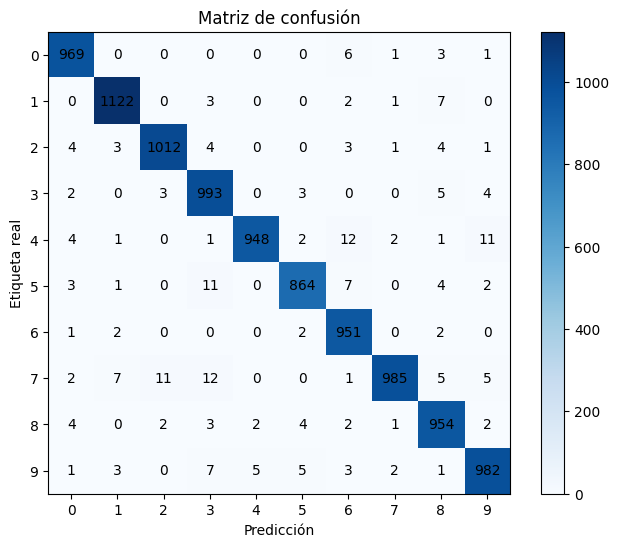

In [17]:
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix.numpy(), cmap="Blues")
plt.colorbar()
plt.xticks(range(num_classes))
plt.yticks(range(num_classes))
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión")
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, int(conf_matrix[i, j]), ha="center", va="center")
plt.show()

Aquí calculamos precision, recall, f1-score y accuracy global sin usar sklearn.

In [18]:
def classification_report_from_confusion_matrix(conf_matrix):
    conf_matrix = conf_matrix.float()
    num_classes = conf_matrix.size(0)
    total = conf_matrix.sum().item()
    correct = torch.diag(conf_matrix).sum().item()
    accuracy = correct / total

    metrics = {}

    for cls in range(num_classes):
        tp = conf_matrix[cls, cls].item()
        fp = conf_matrix[:, cls].sum().item() - tp
        fn = conf_matrix[cls, :].sum().item() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        metrics[cls] = {
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        }

    return accuracy, metrics

Con esto ya imprimimos el reporte de clasificación final.

In [19]:
global_accuracy, class_metrics = classification_report_from_confusion_matrix(conf_matrix)

print(f"Accuracy global: {global_accuracy:.4f}\n")

for cls, values in class_metrics.items():
    print(
        f"Clase {cls} | "
        f"Precision: {values['precision']:.4f} | "
        f"Recall: {values['recall']:.4f} | "
        f"F1-score: {values['f1_score']:.4f}"
    )

Accuracy global: 0.9780

Clase 0 | Precision: 0.9788 | Recall: 0.9888 | F1-score: 0.9838
Clase 1 | Precision: 0.9851 | Recall: 0.9885 | F1-score: 0.9868
Clase 2 | Precision: 0.9844 | Recall: 0.9806 | F1-score: 0.9825
Clase 3 | Precision: 0.9603 | Recall: 0.9832 | F1-score: 0.9716
Clase 4 | Precision: 0.9927 | Recall: 0.9654 | F1-score: 0.9788
Clase 5 | Precision: 0.9818 | Recall: 0.9686 | F1-score: 0.9752
Clase 6 | Precision: 0.9635 | Recall: 0.9927 | F1-score: 0.9779
Clase 7 | Precision: 0.9919 | Recall: 0.9582 | F1-score: 0.9748
Clase 8 | Precision: 0.9675 | Recall: 0.9795 | F1-score: 0.9735
Clase 9 | Precision: 0.9742 | Recall: 0.9732 | F1-score: 0.9737


Reflexión


En esta actividad pude entender mejor todo el flujo completo de entrenamiento de una red neuronal desde cero usando PyTorch. Algo que me quedó bastante claro y reclaco es la importancia de separar correctamente train, validation y test, porque cada uno cumple una función distinta. También vi cómo pequeños cambios en hiperparámetros como el learning rate o el tamaño de la red pueden afectar bastante el rendimiento.

El early stopping me pareció bastante útil porque evita seguir entrenando cuando ya no hay mejoras reales, lo cual ahorra tiempo y recursos. Finalmente, calcular la matriz de confusión y las métricas por clase me ayudó a ver más a fondo cómo se comporta el modelo, no solo en accuracy general sino en cada clase individual.